IndexError: list index out of range

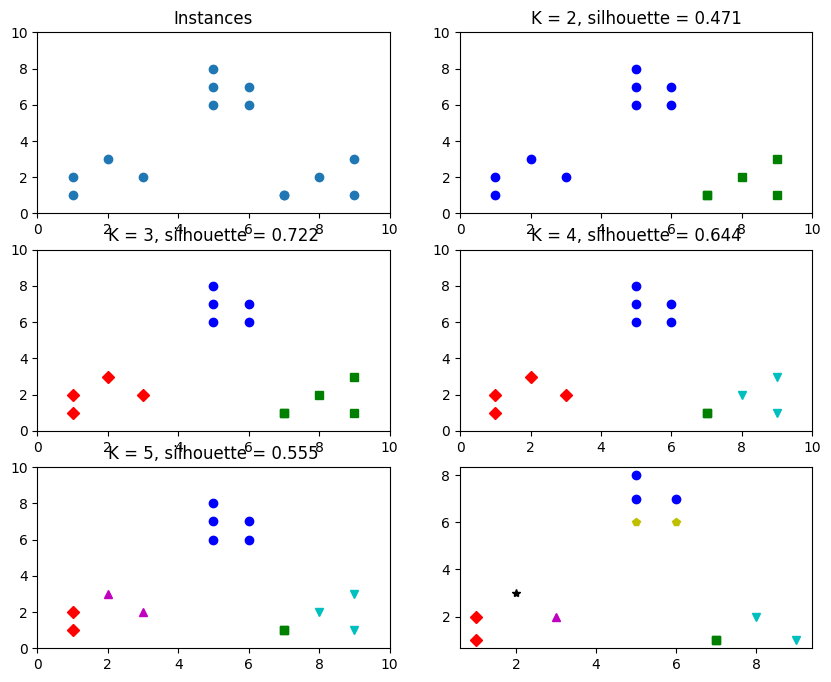

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn import metrics
import matplotlib.pyplot as plt

# Data
x1 = np.array([1, 2, 3, 1, 5, 6, 5, 5, 6, 7, 8, 9, 7, 9])
x2 = np.array([1, 3, 2, 2, 8, 6, 7, 6, 7, 1, 2, 1, 1, 3])

# FIX: proper stacking instead of zip
X = np.column_stack((x1, x2))

plt.figure(figsize=(10, 8))

# Original points
plt.subplot(3, 2, 1)
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.title('Instances')
plt.scatter(x1, x2)

colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
markers = ['o', 's', 'D', 'v', '^', 'p', '*']

tests = [2, 3, 4, 5, 8]
subplot_counter = 1

for t in tests:
    subplot_counter += 1
    plt.subplot(3, 2, subplot_counter)

    kmeans_model = KMeans(n_clusters=t, random_state=42, n_init=10)
    kmeans_model.fit(X)

    for i, label in enumerate(kmeans_model.labels_):
        plt.plot(x1[i], x2[i],
                 color=colors[label],
                 marker=markers[label % len(markers)],
                 linestyle='None')

    plt.xlim([0, 10])
    plt.ylim([0, 10])

    score = metrics.silhouette_score(X, kmeans_model.labels_, metric='euclidean')

    plt.title(f'K = {t}, silhouette = {score:.3f}')

plt.tight_layout()
plt.show()